# LSTM Return Forecasting

Standalone notebook for SBER OHLC forward-return forecasting with PyTorch LSTM models.

The notebook copies only the data loading and feature engineering needed from `ml.ipynb`, then trains one LSTM per horizon: `1d`, `7d`, `14d`, and `30d`. Data is split chronologically into `60%` train, `20%` validation, and `20%` test.

In [1]:
import math
import os
import random
import time
import warnings

import numpy as np
import optuna
import pandas as pd
import plotly.graph_objects as go
import torch
from plotly.subplots import make_subplots
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.INFO)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# CPU keeps this notebook reproducible across local machines and avoids MPS/CUDA
# differences for small time-series experiments.
device = torch.device("cpu")
print("device:", device)

device: cpu


## Data Loading And Feature Processing

This section mirrors only the preprocessing pieces needed for LSTM: load historical daily data, split symbols into separate time series, drop very short histories, keep the most recent 1200 rows, and build OHLC/return/volatility features.

In [2]:
df = pd.read_csv("gen/historical_data_1d.csv", sep=";")
df["begin"] = pd.to_datetime(df["begin"])

series = {}
lens = []
for name in df["name"].unique():
    series[name] = df[df["name"] == name].sort_values("begin").reset_index(drop=True)
    lens.append(len(series[name]))

for short_symbol in ["MBNK", "SVCB"]:
    if short_symbol in series:
        del series[short_symbol]

for name in series:
    series[name] = series[name].tail(1200).reset_index(drop=True)

sym = "SBER"
print("symbols:", sorted(series.keys()))
print(sym, "rows after tail:", len(series[sym]))
display(series[sym].head())

symbols: ['CBOM', 'SBER', 'SBERP', 'T', 'VTBR']
SBER rows after tail: 1200


,begin,open,close,high,low,value,volume,name
0,2021-03-12,286.30,284.93,287.49,282.82,1.469694e+10,51540190,SBER
1,2021-03-15,286.05,292.74,292.92,285.28,1.969448e+10,67805740,SBER
2,2021-03-16,293.06,292.33,293.88,288.61,1.570696e+10,53921730,SBER
3,2021-03-17,292.35,283.35,293.25,279.60,3.142031e+10,110292330,SBER
4,2021-03-18,284.04,279.25,285.79,278.24,2.095219e+10,74128740,SBER


In [3]:
def IntradayReturn(df):
    return df["close"] / df["open"] - 1.0


def OvernightReturn(df):
    return df["open"] / df["close"].shift(1) - 1.0


def Amplitude(df):
    return (df["high"] - df["low"]) / ((df["high"] + df["low"]) / 2.0)


def OHLC(df):
    return (df["open"] + df["close"] + df["low"] + df["high"]) / 4.0


def MedianPrice(df):
    return (df["low"] + df["high"]) / 2.0


def BodyMedian(df):
    return (df["open"] + df["close"]) / 2.0


def RollingVolatility(df, window):
    ret = np.log(df["close"]).diff()
    return ret.rolling(window=window).std() * np.sqrt(252)


def VolatilityParkinson(df, window):
    ret = (1.0 / (4.0 * math.log(2.0))) * np.log(df["high"] / df["low"]) ** 2.0
    return ret.rolling(window=window).apply(lambda x: np.sqrt(252 * x.mean()), raw=False)


def VolatilityGarmanKlass(df, window):
    log_hl = np.log(df["high"] / df["low"])
    log_co = np.log(df["close"] / df["open"])
    ret = 0.5 * log_hl ** 2 - (2 * math.log(2) - 1) * log_co ** 2
    return ret.rolling(window=window).apply(lambda x: np.sqrt(max(252 * x.mean(), 0.0)), raw=False)


for name in series:
    series[name]["intraday"] = IntradayReturn(series[name])
    series[name]["overnight"] = OvernightReturn(series[name])
    series[name]["amplitude"] = Amplitude(series[name])

    series[name]["ohlc"] = OHLC(series[name])
    series[name]["MedianPrice"] = MedianPrice(series[name])
    series[name]["BodyMedian"] = BodyMedian(series[name])

    series[name]["RollingVolatility_7d"] = RollingVolatility(series[name], 7)
    series[name]["RollingVolatility_30d"] = RollingVolatility(series[name], 30)

    series[name]["VolatilityParkinson_7d"] = VolatilityParkinson(series[name], 7)
    series[name]["VolatilityParkinson_30d"] = VolatilityParkinson(series[name], 30)

    series[name]["VolatilityGarmanKlass_7d"] = VolatilityGarmanKlass(series[name], 7)
    series[name]["VolatilityGarmanKlass_30d"] = VolatilityGarmanKlass(series[name], 30)


df_lstm_base = series[sym].copy()
initial_nan_rows = int(df_lstm_base.isna().sum().max())
df_lstm_base = df_lstm_base.tail(len(df_lstm_base) - initial_nan_rows).reset_index(drop=True)
df_lstm_base = (
    df_lstm_base.replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

feature_cols = [col for col in df_lstm_base.columns if col not in ["begin", "name"]]

print("rows after feature cleanup:", len(df_lstm_base))
print("date range:", df_lstm_base["begin"].min(), "->", df_lstm_base["begin"].max())
print("feature columns:", feature_cols)
display(df_lstm_base.head())

rows after feature cleanup: 1170
date range: 2021-04-23 00:00:00 -> 2025-10-13 00:00:00
feature columns: ['open', 'close', 'high', 'low', 'value', 'volume', 'intraday', 'overnight', 'amplitude', 'ohlc', 'MedianPrice', 'BodyMedian', 'RollingVolatility_7d', 'RollingVolatility_30d', 'VolatilityParkinson_7d', 'VolatilityParkinson_30d', 'VolatilityGarmanKlass_7d', 'VolatilityGarmanKlass_30d']


,begin,open,close,high,low,value,volume,name,intraday,overnight,amplitude,ohlc,MedianPrice,BodyMedian,RollingVolatility_7d,RollingVolatility_30d,VolatilityParkinson_7d,VolatilityParkinson_30d,VolatilityGarmanKlass_7d,VolatilityGarmanKlass_30d
0,2021-04-23,293.10,293.19,294.20,290.78,1.247939e+10,42651330,SBER,0.000307,0.003149,0.011693,292.8175,292.490,293.145,0.148770,0.218201,0.156135,0.201951,0.171383,0.200354
1,2021-04-26,294.30,295.27,296.48,293.10,1.348961e+10,45760050,SBER,0.003296,0.003786,0.011466,294.7875,294.790,294.785,0.105267,0.204712,0.151856,0.197652,0.168085,0.198644
2,2021-04-27,295.74,298.50,300.25,295.61,1.873695e+10,62853160,SBER,0.009333,0.001592,0.015574,297.5250,297.930,297.120,0.083161,0.206914,0.148003,0.197000,0.163598,0.197087
3,2021-04-28,299.00,298.49,299.26,295.89,1.208619e+10,40622520,SBER,-0.001706,0.001675,0.011325,298.1600,297.575,298.745,0.073971,0.183565,0.148166,0.179762,0.163688,0.181667
4,2021-04-29,301.00,297.10,301.84,294.79,1.703547e+10,57082260,SBER,-0.012957,0.008409,0.023633,298.6825,298.315,299.050,0.088660,0.178079,0.162129,0.178424,0.175505,0.180900


## Metrics And Sequence Builder

Each sample contains a rolling feature window ending at date `t`. The target is the forward OHLC return:

`ohlc[t + horizon] / ohlc[t] - 1`.

The split is chronological `60/20/20`; scalers are fit only on train data.

In [4]:
def return_smape(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return np.mean(200.0 * np.abs(y_pred - y_true) / denom)


def add_return_metrics(name, y_true, y_pred, df_metrics):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    df_metrics.loc[name] = [
        mean_squared_error(y_true, y_pred),
        mean_absolute_error(y_true, y_pred),
        return_smape(y_true, y_pred),
    ]


def split_positions(n_samples, train_ratio=0.60, val_ratio=0.20):
    train_end = int(n_samples * train_ratio)
    val_end = int(n_samples * (train_ratio + val_ratio))
    if train_end <= 0 or val_end <= train_end or val_end >= n_samples:
        raise ValueError(f"Bad split for {n_samples} samples")
    return train_end, val_end


def transform_sequences(scaler, x):
    n_samples, lookback, n_features = x.shape
    x_scaled = scaler.transform(x.reshape(-1, n_features))
    return x_scaled.reshape(n_samples, lookback, n_features).astype(np.float32)


def build_lstm_return_data(
    df,
    horizon,
    lookback,
    feature_cols,
    train_ratio=0.60,
    val_ratio=0.20,
):
    df = df.sort_values("begin").reset_index(drop=True).copy()
    features = df[feature_cols].astype(float).to_numpy()
    ohlc = df["ohlc"].astype(float).to_numpy()
    timestamps = df["begin"].to_numpy()

    x_values = []
    y_returns = []
    current_ohlc = []
    target_ohlc = []
    target_timestamps = []

    for end_pos in range(lookback - 1, len(df) - horizon):
        start_pos = end_pos - lookback + 1
        future_pos = end_pos + horizon
        target_return = ohlc[future_pos] / ohlc[end_pos] - 1.0

        x_values.append(features[start_pos : end_pos + 1])
        y_returns.append(target_return)
        current_ohlc.append(ohlc[end_pos])
        target_ohlc.append(ohlc[future_pos])
        target_timestamps.append(timestamps[end_pos])

    x_values = np.asarray(x_values, dtype=np.float32)
    y_returns = np.asarray(y_returns, dtype=np.float32)
    current_ohlc = np.asarray(current_ohlc, dtype=np.float32)
    target_ohlc = np.asarray(target_ohlc, dtype=np.float32)
    target_timestamps = pd.to_datetime(pd.Series(target_timestamps))

    finite_mask = np.isfinite(x_values).all(axis=(1, 2)) & np.isfinite(y_returns)
    x_values = x_values[finite_mask]
    y_returns = y_returns[finite_mask]
    current_ohlc = current_ohlc[finite_mask]
    target_ohlc = target_ohlc[finite_mask]
    target_timestamps = target_timestamps.loc[finite_mask].reset_index(drop=True)

    train_end, val_end = split_positions(len(y_returns), train_ratio, val_ratio)
    split_idx = {
        "train": slice(0, train_end),
        "val": slice(train_end, val_end),
        "test": slice(val_end, len(y_returns)),
    }

    x_train_raw = x_values[split_idx["train"]]
    y_train_raw = y_returns[split_idx["train"]]

    feature_scaler = StandardScaler()
    feature_scaler.fit(x_train_raw.reshape(-1, x_train_raw.shape[-1]))

    target_scaler = StandardScaler()
    target_scaler.fit(y_train_raw.reshape(-1, 1))

    result = {
        "horizon": horizon,
        "lookback": lookback,
        "feature_cols": list(feature_cols),
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler,
        "n_features": x_values.shape[-1],
    }

    for split_name, split_slice in split_idx.items():
        x_split = x_values[split_slice]
        y_split = y_returns[split_slice]
        result[f"X_{split_name}"] = transform_sequences(feature_scaler, x_split)
        result[f"y_{split_name}"] = target_scaler.transform(y_split.reshape(-1, 1)).ravel().astype(np.float32)
        result[f"y_{split_name}_return"] = y_split.astype(float)
        result[f"current_ohlc_{split_name}"] = current_ohlc[split_slice].astype(float)
        result[f"target_ohlc_{split_name}"] = target_ohlc[split_slice].astype(float)
        result[f"ts_{split_name}"] = target_timestamps.iloc[split_slice].reset_index(drop=True)

    return result

## LSTM Model

The `nn.Linear(hidden_size, 1)` layer is the regression head. It is not a separate linear model. The LSTM turns a sequence into hidden features; the head maps the final hidden feature vector to one scalar continuous forecast and is trained together with the LSTM.

In [5]:
class ReturnLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=lstm_dropout,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.lstm(x)
        last_hidden = output[:, -1, :]
        return self.head(last_hidden).squeeze(-1)


def make_loader(x, y, batch_size, shuffle=False):
    dataset = TensorDataset(
        torch.as_tensor(x, dtype=torch.float32),
        torch.as_tensor(y, dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_count = 0
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            total_loss += loss.item() * len(y_batch)
            total_count += len(y_batch)
    return total_loss / max(total_count, 1)


def train_lstm_model(
    data,
    params,
    max_epochs=100,
    patience=12,
    verbose=False,
):
    torch.manual_seed(RANDOM_STATE)
    model = ReturnLSTM(
        input_size=data["n_features"],
        hidden_size=int(params["hidden_size"]),
        num_layers=int(params["num_layers"]),
        dropout=float(params["dropout"]),
    ).to(device)

    batch_size = int(params["batch_size"])
    train_loader = make_loader(data["X_train"], data["y_train"], batch_size=batch_size, shuffle=False)
    val_loader = make_loader(data["X_val"], data["y_val"], batch_size=batch_size, shuffle=False)

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(params["learning_rate"]),
        weight_decay=float(params["weight_decay"]),
    )

    best_val_loss = np.inf
    best_epoch = 0
    best_state = None
    no_improve = 0
    train_losses = []
    val_losses = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss = 0.0
        epoch_count = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item() * len(y_batch)
            epoch_count += len(y_batch)

        train_loss = epoch_loss / max(epoch_count, 1)
        val_loss = evaluate_loss(model, val_loader, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss - 1e-8:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(f"epoch={epoch:03d} train_loss={train_loss:.6f} val_loss={val_loss:.6f}")

        if no_improve >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "best_val_loss": float(best_val_loss),
        "best_epoch": int(best_epoch),
        "epochs_ran": len(train_losses),
    }
    return model, history


def predict_lstm_returns(model, data, split_name="test", batch_size=64):
    x = data[f"X_{split_name}"]
    dummy_y = np.zeros(len(x), dtype=np.float32)
    loader = make_loader(x, dummy_y, batch_size=batch_size, shuffle=False)

    model.eval()
    scaled_preds = []
    with torch.no_grad():
        for x_batch, _ in loader:
            pred = model(x_batch.to(device)).cpu().numpy()
            scaled_preds.append(pred)

    scaled_preds = np.concatenate(scaled_preds)
    return data["target_scaler"].inverse_transform(scaled_preds.reshape(-1, 1)).ravel()

## Optuna Search And Final Training

In [6]:
def make_lstm_objective(df, horizon, feature_cols):
    def objective(trial):
        params = {
            "lookback": trial.suggest_categorical("lookback", [30, 60, 90]),
            "hidden_size": trial.suggest_categorical("hidden_size", [32, 64, 128]),
            "num_layers": trial.suggest_int("num_layers", 1, 2),
            "dropout": trial.suggest_float("dropout", 0.0, 0.35),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
        }
        data = build_lstm_return_data(
            df=df,
            horizon=horizon,
            lookback=params["lookback"],
            feature_cols=feature_cols,
        )
        _, history = train_lstm_model(
            data=data,
            params=params,
            max_epochs=80,
            patience=10,
            verbose=False,
        )
        trial.set_user_attr("best_epoch", history["best_epoch"])
        trial.set_user_attr("epochs_ran", history["epochs_ran"])
        return history["best_val_loss"]

    return objective


def format_seconds(seconds):
    seconds = int(round(seconds))
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    if hours:
        return f"{hours}h {minutes}m {seconds}s"
    if minutes:
        return f"{minutes}m {seconds}s"
    return f"{seconds}s"


horizon_config = [1, 7, 14, 30]
n_trials_lstm = int(os.environ.get("N_TRIALS_LSTM", 8))

lstm_return_datasets = {}
lstm_return_models = {}
lstm_return_predictions = {}
lstm_return_price_predictions = {}
lstm_return_best_params = {}
lstm_return_studies = {}
lstm_return_histories = {}
lstm_return_timings = []

df_metrics_lstm_return = pd.DataFrame(columns=["MSE", "MAE", "sMAPE"])

print(f"Optuna trials per horizon: {n_trials_lstm}")
timing_start = time.perf_counter()

for horizon_idx, horizon in enumerate(horizon_config, start=1):
    horizon_start = time.perf_counter()
    print(f"\nHorizon {horizon}d ({horizon_idx}/{len(horizon_config)})")
    study = optuna.create_study(
        direction="minimize",
        study_name=f"lstm_return_{horizon}d",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )

    optuna_start = time.perf_counter()
    study.optimize(
        make_lstm_objective(df_lstm_base, horizon, feature_cols),
        n_trials=n_trials_lstm,
        show_progress_bar=False,
    )
    optuna_seconds = time.perf_counter() - optuna_start

    best_params = dict(study.best_params)
    data = build_lstm_return_data(
        df=df_lstm_base,
        horizon=horizon,
        lookback=best_params["lookback"],
        feature_cols=feature_cols,
    )

    final_train_start = time.perf_counter()
    model, history = train_lstm_model(
        data=data,
        params=best_params,
        max_epochs=120,
        patience=15,
        verbose=False,
    )
    final_train_seconds = time.perf_counter() - final_train_start

    y_pred = predict_lstm_returns(
        model=model,
        data=data,
        split_name="test",
        batch_size=best_params["batch_size"],
    )
    y_test = data["y_test_return"]
    ts_test = data["ts_test"]

    pred_series = pd.Series(y_pred, index=ts_test, name=f"lstm_return_{horizon}d")
    price_pred_series = pd.Series(
        data["current_ohlc_test"] * (1.0 + y_pred),
        index=ts_test,
        name=f"lstm_price_{horizon}d",
    )

    lstm_return_datasets[horizon] = data
    lstm_return_models[horizon] = model
    lstm_return_predictions[horizon] = pred_series
    lstm_return_price_predictions[horizon] = price_pred_series
    lstm_return_studies[horizon] = study
    lstm_return_histories[horizon] = history
    lstm_return_best_params[horizon] = {
        "best_val_mse_scaled": study.best_value,
        "final_best_val_mse_scaled": history["best_val_loss"],
        "best_epoch": history["best_epoch"],
        **best_params,
    }

    add_return_metrics(
        f"zero_baseline_{horizon}d",
        y_test,
        np.zeros(len(y_test), dtype=float),
        df_metrics_lstm_return,
    )
    add_return_metrics(f"lstm_{horizon}d", y_test, y_pred, df_metrics_lstm_return)

    horizon_seconds = time.perf_counter() - horizon_start
    elapsed_seconds = time.perf_counter() - timing_start
    avg_horizon_seconds = elapsed_seconds / horizon_idx
    remaining_horizons = len(horizon_config) - horizon_idx
    estimated_remaining_seconds = avg_horizon_seconds * remaining_horizons

    lstm_return_timings.append({
        "horizon": horizon,
        "trials": n_trials_lstm,
        "optuna_seconds": optuna_seconds,
        "final_train_seconds": final_train_seconds,
        "total_horizon_seconds": horizon_seconds,
        "elapsed_seconds": elapsed_seconds,
        "estimated_remaining_seconds": estimated_remaining_seconds,
    })

    print("samples:", {
        "train": len(data["y_train_return"]),
        "val": len(data["y_val_return"]),
        "test": len(data["y_test_return"]),
    })
    print("best params:", best_params)
    print("best validation MSE, scaled:", round(history["best_val_loss"], 6))
    print(
        "time:",
        f"optuna={format_seconds(optuna_seconds)},",
        f"final_train={format_seconds(final_train_seconds)},",
        f"horizon_total={format_seconds(horizon_seconds)}",
    )
    print(
        "progress:",
        f"elapsed={format_seconds(elapsed_seconds)},",
        f"estimated_remaining={format_seconds(estimated_remaining_seconds)}",
    )

total_seconds = time.perf_counter() - timing_start
print("\nTotal Optuna + final training time:", format_seconds(total_seconds))

lstm_return_best_params_df = pd.DataFrame(lstm_return_best_params).T
lstm_return_timings_df = pd.DataFrame(lstm_return_timings).set_index("horizon")
for col in [
    "optuna_seconds",
    "final_train_seconds",
    "total_horizon_seconds",
    "elapsed_seconds",
    "estimated_remaining_seconds",
]:
    lstm_return_timings_df[col.replace("seconds", "time")] = lstm_return_timings_df[col].map(format_seconds)

display(lstm_return_best_params_df)
display(lstm_return_timings_df)
display(df_metrics_lstm_return)

[I 2026-05-11 23:54:43,049] A new study created in memory with name: lstm_return_1d


Optuna trials per horizon: 8

Horizon 1d (1/4)


[I 2026-05-11 23:54:46,513] Trial 0 finished with value: 0.22461455120696677 and parameters: {'lookback': 60, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.3031616510212273, 'learning_rate': 0.0007725378389307352, 'weight_decay': 0.00013311216080736876, 'batch_size': 32}. Best is trial 0 with value: 0.22461455120696677.
[I 2026-05-11 23:54:50,930] Trial 1 finished with value: 0.2363441450554028 and parameters: {'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.21414851315283281, 'learning_rate': 0.000160712385120399, 'weight_decay': 7.523742884534855e-06, 'batch_size': 64}. Best is trial 0 with value: 0.22461455120696677.
[I 2026-05-11 23:54:54,481] Trial 2 finished with value: 0.25194053407068606 and parameters: {'lookback': 90, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.3321099380386666, 'learning_rate': 0.0026690431824362526, 'weight_decay': 0.0002661901888489054, 'batch_size': 64}. Best is trial 0 with value: 0.22461455120696677.
[I 2026-05-11 23:55:10,163] 

samples: {'train': 684, 'val': 228, 'test': 228}
best params: {'lookback': 30, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.1138656157671425, 'learning_rate': 0.00037507963596256056, 'weight_decay': 6.51699061117717e-06, 'batch_size': 16}
best validation MSE, scaled: 0.222401
time: optuna=53s, final_train=4s, horizon_total=56s
progress: elapsed=56s, estimated_remaining=2m 49s

Horizon 7d (2/4)


[I 2026-05-11 23:55:40,348] Trial 0 finished with value: 0.4517806749538059 and parameters: {'lookback': 60, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.3031616510212273, 'learning_rate': 0.0007725378389307352, 'weight_decay': 0.00013311216080736876, 'batch_size': 32}. Best is trial 0 with value: 0.4517806749538059.
[I 2026-05-11 23:55:41,751] Trial 1 finished with value: 0.4316061987225705 and parameters: {'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.21414851315283281, 'learning_rate': 0.000160712385120399, 'weight_decay': 7.523742884534855e-06, 'batch_size': 64}. Best is trial 1 with value: 0.4316061987225705.
[I 2026-05-11 23:55:43,441] Trial 2 finished with value: 0.4754306759945182 and parameters: {'lookback': 90, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.3321099380386666, 'learning_rate': 0.0026690431824362526, 'weight_decay': 0.0002661901888489054, 'batch_size': 64}. Best is trial 1 with value: 0.4316061987225705.
[I 2026-05-11 23:55:47,634] Trial

...

[I 2026-05-11 23:56:15,165] Trial 0 finished with value: 0.40111826415415164 and parameters: {'lookback': 60, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.3031616510212273, 'learning_rate': 0.0007725378389307352, 'weight_decay': 0.00013311216080736876, 'batch_size': 32}. Best is trial 0 with value: 0.40111826415415164.
[I 2026-05-11 23:56:16,945] Trial 1 finished with value: 0.36230866919766674 and parameters: {'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.21414851315283281, 'learning_rate': 0.000160712385120399, 'weight_decay': 7.523742884534855e-06, 'batch_size': 64}. Best is trial 1 with value: 0.36230866919766674.
[I 2026-05-11 23:56:18,754] Trial 2 finished with value: 0.38308918532871067 and parameters: {'lookback': 90, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.3321099380386666, 'learning_rate': 0.0026690431824362526, 'weight_decay': 0.0002661901888489054, 'batch_size': 64}. Best is trial 1 with value: 0.36230866919766674.
[I 2026-05-11 23:56:24,081]

samples: {'train': 630, 'val': 210, 'test': 211}
best params: {'lookback': 90, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.10909887663129383, 'learning_rate': 0.0005864129169696525, 'weight_decay': 4.366473592979636e-05, 'batch_size': 32}
best validation MSE, scaled: 0.36118
time: optuna=17s, final_train=7s, horizon_total=24s
progress: elapsed=1m 56s, estimated_remaining=0s

Total Optuna + final training time: 1m 56s


,best_val_mse_scaled,final_best_val_mse_scaled,best_epoch,lookback,hidden_size,num_layers,dropout,learning_rate,weight_decay,batch_size
1,0.222401,0.222401,31.0,30.0,32.0,1.0,0.113866,0.000375,0.000007,16.0
7,0.431606,0.431606,16.0,30.0,64.0,1.0,0.214149,0.000161,0.000008,64.0
14,0.411038,0.411038,17.0,30.0,64.0,1.0,0.214149,0.000161,0.000008,64.0
30,0.361180,0.361180,5.0,90.0,64.0,2.0,0.109099,0.000586,0.000044,32.0


,trials,optuna_seconds,final_train_seconds,total_horizon_seconds,elapsed_seconds,estimated_remaining_seconds,optuna_time,final_train_time,total_horizon_time,elapsed_time,estimated_remaining_time
horizon,,,,,,,,,,,
1,8,52.520274,3.786312,56.324899,56.325084,168.975251,53s,4s,56s,56s,2m 49s
7,8,16.150169,1.715465,17.880911,74.206140,74.206140,16s,2s,18s,1m 14s,1m 14s
14,8,15.191922,1.754405,16.962017,91.168267,30.389422,15s,2s,17s,1m 31s,30s
30,8,17.173277,7.224340,24.448808,115.617181,0.000000,17s,7s,24s,1m 56s,0s


,MSE,MAE,sMAPE
zero_baseline_1d,0.000102,0.007048,199.123002
lstm_1d,0.000080,0.005647,116.893147
zero_baseline_7d,0.001031,0.024436,200.000000
lstm_7d,0.001010,0.024622,172.824364
zero_baseline_14d,0.002012,0.032353,200.000000
lstm_14d,0.002066,0.033915,169.243511
zero_baseline_30d,0.003000,0.041729,200.000000
lstm_30d,0.009597,0.084809,157.843996


## Return Forecast Plots

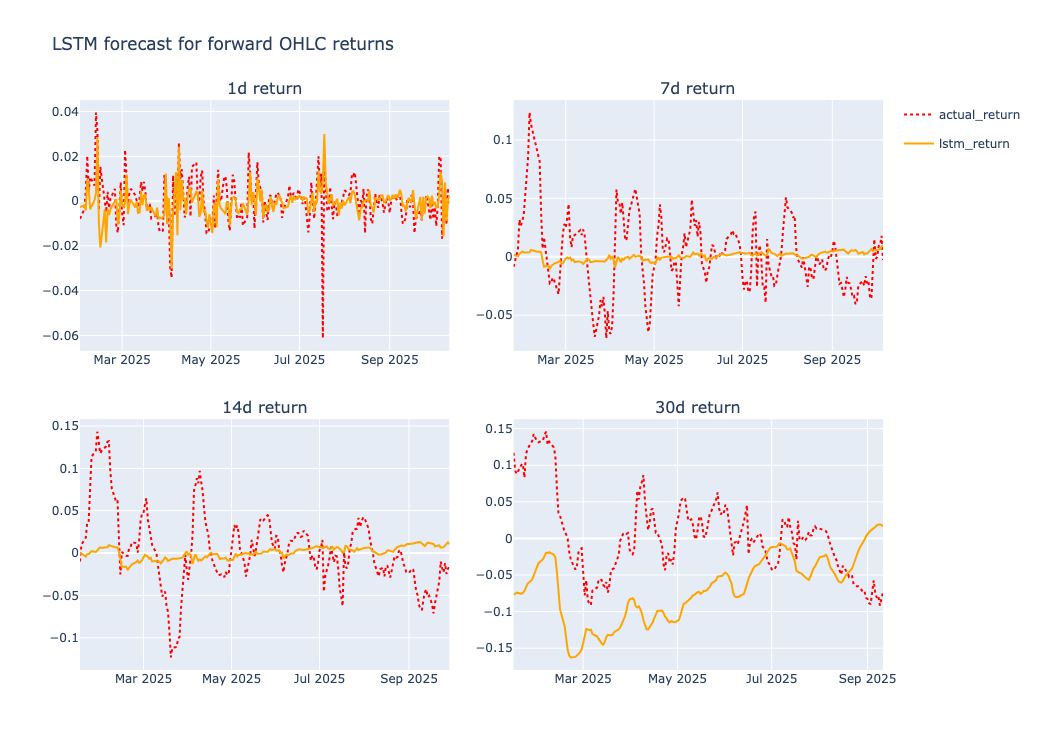

In [7]:
fig_return = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f"{horizon}d return" for horizon in horizon_config],
    horizontal_spacing=0.08,
    vertical_spacing=0.12,
)

for plot_idx, horizon in enumerate(horizon_config, start=1):
    data = lstm_return_datasets[horizon]
    row = (plot_idx - 1) // 2 + 1
    col = (plot_idx - 1) % 2 + 1

    fig_return.add_trace(
        go.Scatter(
            x=data["ts_test"],
            y=data["y_test_return"],
            mode="lines",
            name="actual_return",
            legendgroup="actual_return",
            showlegend=(plot_idx == 1),
            line=dict(color="red", dash="dot"),
        ),
        row=row,
        col=col,
    )
    fig_return.add_trace(
        go.Scatter(
            x=lstm_return_predictions[horizon].index,
            y=lstm_return_predictions[horizon].values,
            mode="lines",
            name="lstm_return",
            legendgroup="lstm_return",
            showlegend=(plot_idx == 1),
            line=dict(color="orange"),
        ),
        row=row,
        col=col,
    )

fig_return.update_layout(
    width=1100,
    height=750,
    title="LSTM forecast for forward OHLC returns",
)
fig_return.show()

## Linear-Style Price Plots

Predicted returns are converted back to price level with:

`predicted_ohlc = current_ohlc * (1 + predicted_return)`.

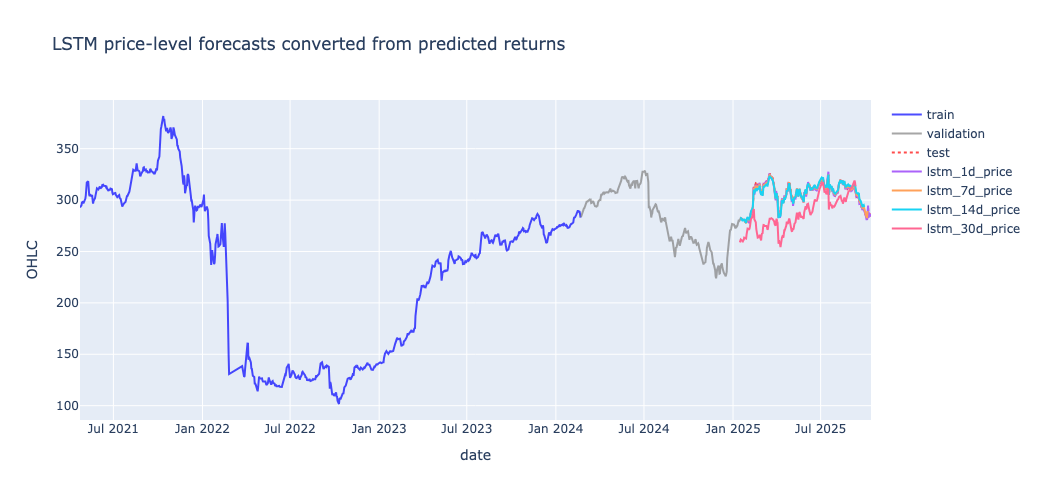

In [8]:
base_train_end, base_val_end = split_positions(len(df_lstm_base), train_ratio=0.60, val_ratio=0.20)

fig_price_combined = go.Figure()
fig_price_combined.add_trace(go.Scatter(
    x=df_lstm_base["begin"].iloc[:base_train_end],
    y=df_lstm_base["ohlc"].iloc[:base_train_end],
    mode="lines",
    name="train",
    line=dict(color="blue"),
    opacity=0.7,
))
fig_price_combined.add_trace(go.Scatter(
    x=df_lstm_base["begin"].iloc[base_train_end:base_val_end],
    y=df_lstm_base["ohlc"].iloc[base_train_end:base_val_end],
    mode="lines",
    name="validation",
    line=dict(color="gray"),
    opacity=0.7,
))
fig_price_combined.add_trace(go.Scatter(
    x=df_lstm_base["begin"].iloc[base_val_end:],
    y=df_lstm_base["ohlc"].iloc[base_val_end:],
    mode="lines",
    name="test",
    line=dict(color="red", dash="dot"),
    opacity=0.7,
))

for horizon in horizon_config:
    fig_price_combined.add_trace(go.Scatter(
        x=lstm_return_price_predictions[horizon].index,
        y=lstm_return_price_predictions[horizon].values,
        mode="lines",
        name=f"lstm_{horizon}d_price",
    ))

fig_price_combined.update_layout(
    width=1000,
    height=500,
    title="LSTM price-level forecasts converted from predicted returns",
    xaxis_title="date",
    yaxis_title="OHLC",
)
fig_price_combined.show()

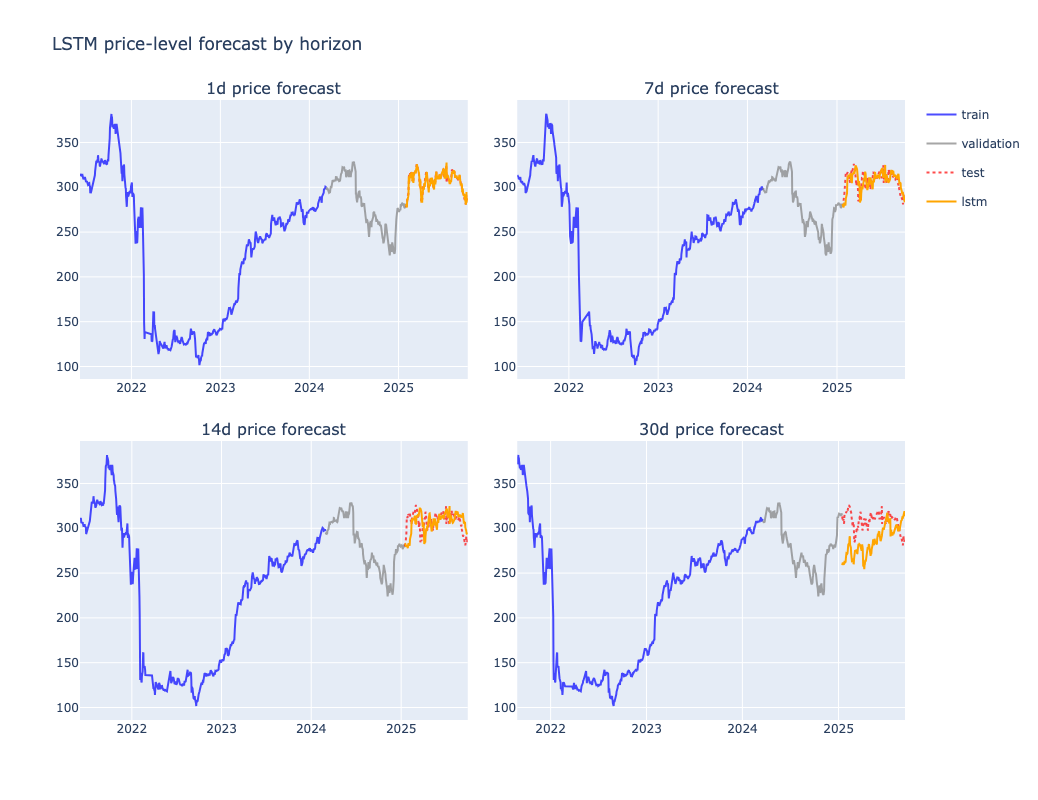

In [9]:
fig_price_grid = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f"{horizon}d price forecast" for horizon in horizon_config],
    horizontal_spacing=0.06,
    vertical_spacing=0.10,
)

for plot_idx, horizon in enumerate(horizon_config, start=1):
    data = lstm_return_datasets[horizon]
    row = (plot_idx - 1) // 2 + 1
    col = (plot_idx - 1) % 2 + 1

    fig_price_grid.add_trace(go.Scatter(
        x=data["ts_train"],
        y=data["target_ohlc_train"],
        mode="lines",
        name="train",
        legendgroup="train",
        showlegend=(plot_idx == 1),
        line=dict(color="blue"),
        opacity=0.7,
    ), row=row, col=col)

    fig_price_grid.add_trace(go.Scatter(
        x=data["ts_val"],
        y=data["target_ohlc_val"],
        mode="lines",
        name="validation",
        legendgroup="validation",
        showlegend=(plot_idx == 1),
        line=dict(color="gray"),
        opacity=0.7,
    ), row=row, col=col)

    fig_price_grid.add_trace(go.Scatter(
        x=data["ts_test"],
        y=data["target_ohlc_test"],
        mode="lines",
        name="test",
        legendgroup="test",
        showlegend=(plot_idx == 1),
        line=dict(color="red", dash="dot"),
        opacity=0.7,
    ), row=row, col=col)

    fig_price_grid.add_trace(go.Scatter(
        x=lstm_return_price_predictions[horizon].index,
        y=lstm_return_price_predictions[horizon].values,
        mode="lines",
        name="lstm",
        legendgroup="lstm",
        showlegend=(plot_idx == 1),
        line=dict(color="orange"),
    ), row=row, col=col)

fig_price_grid.update_layout(
    width=1100,
    height=800,
    title="LSTM price-level forecast by horizon",
)
fig_price_grid.show()

## Training Curves

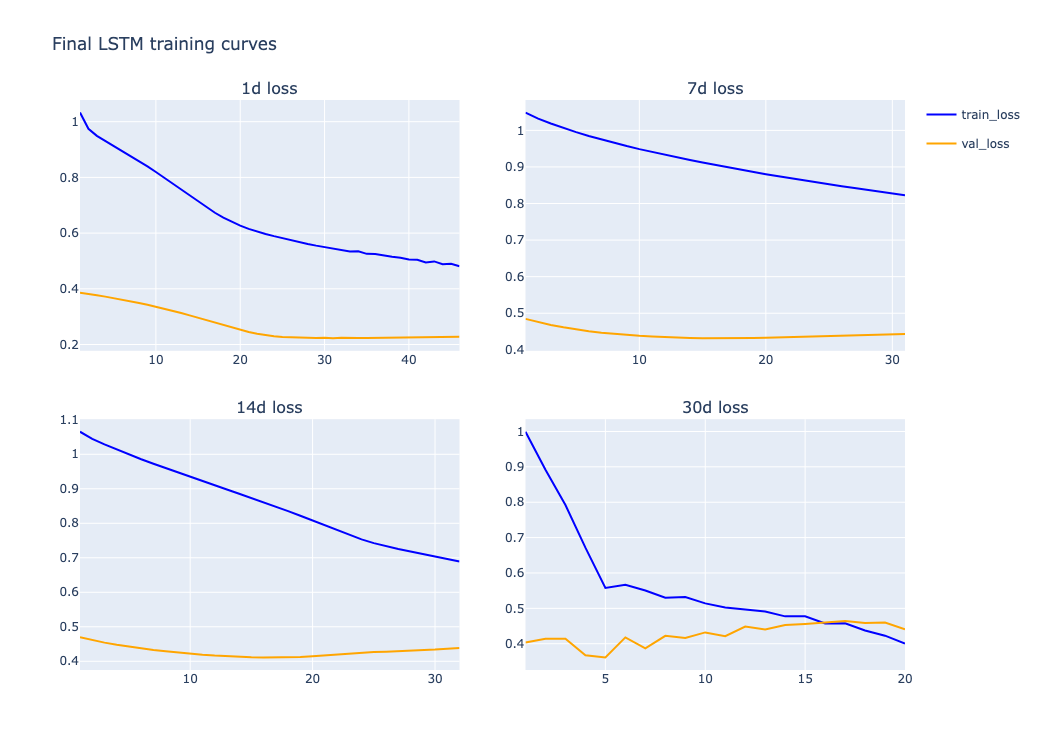

In [10]:
fig_loss = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f"{horizon}d loss" for horizon in horizon_config],
    horizontal_spacing=0.08,
    vertical_spacing=0.12,
)

for plot_idx, horizon in enumerate(horizon_config, start=1):
    history = lstm_return_histories[horizon]
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    row = (plot_idx - 1) // 2 + 1
    col = (plot_idx - 1) % 2 + 1

    fig_loss.add_trace(go.Scatter(
        x=epochs,
        y=history["train_loss"],
        mode="lines",
        name="train_loss",
        legendgroup="train_loss",
        showlegend=(plot_idx == 1),
        line=dict(color="blue"),
    ), row=row, col=col)

    fig_loss.add_trace(go.Scatter(
        x=epochs,
        y=history["val_loss"],
        mode="lines",
        name="val_loss",
        legendgroup="val_loss",
        showlegend=(plot_idx == 1),
        line=dict(color="orange"),
    ), row=row, col=col)

fig_loss.update_layout(
    width=1100,
    height=750,
    title="Final LSTM training curves",
)
fig_loss.show()